In [2]:
import os
import random
from pathlib import Path
from random import randint
from types import SimpleNamespace

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image, ImageFile
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

from evaluation import psnr, ssim, fid_from_images

ImageFile.LOAD_TRUNCATED_IMAGES = True


## Data Preprocessing & Masking

### Mask Generation
Creates the binary hole masks used for inpainting.
- Each helper returns `1` for known pixels and `0` for missing regions.
- Includes followinf masks:

    - **random_regular_mask**: Places 1 to 5 non-overlapping rectangular blocks of random sizes and coordinates to simulate simple windowed occlusions.
    - **center_mask**: Places a single, rigid square mask covering exactly the center 50% of the image.
    - **random_irregular_mask**: Randomly samples geometric shapes (lines, solid circles, and ellipses of varying thicknesses) to composite together highly irregular, abstract hole shapes.
    - **random_freefrom_mask**: Simulates organic, hand-drawn brush strokes by drawing continuous, jagged paths with varying stroke widths and traversal angles.

In [2]:
# Generate mask variants used by the dataset.
def random_regular_mask(img):
    s = img.size()
    mask = torch.ones(1, s[1], s[2])
    n_mask = random.randint(1, 5)
    limx = s[1] - s[1] / (n_mask + 1)
    limy = s[2] - s[2] / (n_mask + 1)
    for _ in range(n_mask):
        x = random.randint(0, int(limx))
        y = random.randint(0, int(limy))
        range_x = x + random.randint(int(s[1] / (n_mask + 7)), int(s[1] - x))
        range_y = y + random.randint(int(s[2] / (n_mask + 7)), int(s[2] - y))
        mask[:, int(x):int(range_x), int(y):int(range_y)] = 0
    return mask


def center_mask(img):
    size = img.size()
    mask = torch.ones(1, size[1], size[2])
    x = int(size[1] / 4)
    y = int(size[2] / 4)
    range_x = int(size[1] * 3 / 4)
    range_y = int(size[2] * 3 / 4)
    mask[:, x:range_x, y:range_y] = 0
    return mask


def random_irregular_mask(img):
    to_tensor = transforms.Compose([transforms.ToTensor()])
    size = img.size()
    mask = torch.ones(1, size[1], size[2])
    canvas = np.zeros((size[1], size[2], 1), np.uint8)

    max_width = 20
    if size[1] < 64 or size[2] < 64:
        raise Exception('Width and Height of mask must be at least 64!')

    # Draw a mix of lines, circles, and ellipses to form free-form holes.
    number = random.randint(16, 64)
    for _ in range(number):
        mode = random.random()
        if mode < 0.6:
            x1, x2 = randint(1, size[1]), randint(1, size[1])
            y1, y2 = randint(1, size[2]), randint(1, size[2])
            thickness = randint(4, max_width)
            cv2.line(canvas, (x1, y1), (x2, y2), (1, 1, 1), thickness)
        elif mode < 0.8:
            x1, y1 = randint(1, size[1]), randint(1, size[2])
            radius = randint(4, max_width)
            cv2.circle(canvas, (x1, y1), radius, (1, 1, 1), -1)
        else:
            x1, y1 = randint(1, size[1]), randint(1, size[2])
            s1, s2 = randint(1, size[1]), randint(1, size[2])
            a1, a2, a3 = randint(3, 180), randint(3, 180), randint(3, 180)
            thickness = randint(4, max_width)
            cv2.ellipse(canvas, (x1, y1), (s1, s2), a1, a2, a3, (1, 1, 1), thickness)

    canvas = canvas.reshape(size[2], size[1])
    pil_mask = Image.fromarray(canvas * 255)
    img_mask = to_tensor(pil_mask)
    mask[0, :, :] = img_mask < 1
    return mask


def random_freefrom_mask(img, mv=5, ma=4.0, ml=40, mbw=10):
    to_tensor = transforms.Compose([transforms.ToTensor()])
    size = img.size()
    mask = torch.ones(1, size[1], size[2])
    canvas = np.zeros((size[1], size[2], 1), np.uint8)
    num_v = 12 + np.random.randint(mv)

    # Trace multiple random brush strokes to create larger irregular holes.
    for i in range(num_v):
        start_x = np.random.randint(size[1])
        start_y = np.random.randint(size[2])
        for _ in range(1 + np.random.randint(5)):
            angle = 0.01 + np.random.randint(ma)
            if i % 2 == 0:
                angle = 2 * 3.1415926 - angle
            length = 10 + np.random.randint(ml)
            brush_w = 10 + np.random.randint(mbw)
            end_x = (start_x + length * np.sin(angle)).astype(np.int32)
            end_y = (start_y + length * np.cos(angle)).astype(np.int32)

            cv2.line(canvas, (start_y, start_x), (end_y, end_x), 1.0, brush_w)
            start_x, start_y = end_x, end_y

    canvas = canvas.reshape(size[2], size[1])
    pil_mask = Image.fromarray(canvas * 255)
    img_mask = to_tensor(pil_mask)
    mask[0, :, :] = img_mask < 1
    return mask


### Dataset and Dataloader
Configures the data pipeline for loading, augmenting, and batching images with randomly sampled masks.

- **`_build_transform`**: Preprocesses images (resize, random crop) and applies training augmentations (color jitter, flip, rotate).
- **`SimpleInpaintDataset`**: Loads images and pairs each dynamically with one randomly generated mask type.
- **`make_dataloader`**: Initializes the PyTorch `DataLoader` with parallel workers and memory pinning for fast, efficient batching.


In [3]:
# Apply resize, augmentation, and tensor conversion for each image sample.
def _build_transform(opt):
    transform_list = []
    load_size = [opt.loadSize[0], opt.loadSize[1]]
    fine_size = [opt.fineSize[0], opt.fineSize[1]]

    if opt.isTrain:
        if opt.resize_or_crop == 'resize_and_crop':
            transform_list.append(transforms.Resize(load_size))
            transform_list.append(transforms.RandomCrop(fine_size))
        elif opt.resize_or_crop == 'crop':
            transform_list.append(transforms.RandomCrop(fine_size))

        if not getattr(opt, 'no_augment', False):
            transform_list.append(transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2))
        if not getattr(opt, 'no_flip', False):
            transform_list.append(transforms.RandomHorizontalFlip())
        if not getattr(opt, 'no_rotation', False):
            transform_list.append(transforms.RandomRotation(3))
    else:
        transform_list.append(transforms.Resize(fine_size))

    transform_list.append(transforms.ToTensor())
    return transforms.Compose(transform_list)


# Pair each image with one randomly selected mask type.
class SimpleInpaintDataset(data.Dataset):
    def __init__(self, opt):
        self.opt = opt
        self.img_paths = sorted(
            os.path.join(opt.img_file, f)
            for f in os.listdir(opt.img_file)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        )
        self.transform = _build_transform(opt)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, index):
        img_path = self.img_paths[index]
        with Image.open(img_path).convert('RGB') as pil_img:
            img = self.transform(pil_img)

        # Sample one mask type per image so the training holes vary across iterations.
        mask_type = random.choice(self.opt.mask_type)
        if mask_type == 0:
            mask = center_mask(img)
        elif mask_type == 1:
            mask = random_regular_mask(img)
        elif mask_type == 2:
            mask = random_irregular_mask(img)
        elif mask_type == 4:
            mask = random_freefrom_mask(img)
        else:
            raise ValueError(f'Unsupported mask_type in simplified loader: {mask_type}')

        return {'img': img, 'img_path': img_path, 'mask': mask}


# Build the dataloader with the dataset and worker settings.
def make_dataloader(opt):
    dataset = SimpleInpaintDataset(opt)
    num_workers = int(opt.nThreads)
    loader_kwargs = dict(
        batch_size=opt.batchSize,
        shuffle=not opt.no_shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    if num_workers > 0:
        loader_kwargs['persistent_workers'] = True
        loader_kwargs['prefetch_factor'] = 2

    return data.DataLoader(dataset, **loader_kwargs)



## Model Architecture
Spa-Former for image inpainting.
- Generator: encoder-decoder with skip connections.
- Gated Transformer blocks which use channel attention are used in the Generator
- Discriminator: PatchGAN-style conv network.


In [4]:
# Normalize each sample across channels before attention and FFN blocks.
class ChannelLayerNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gn = nn.GroupNorm(1, dim)

    def forward(self, x):
        return self.gn(x)

### Spa-Attention Module
Sparse channel attention block used inside transformer layers.
- Builds attention with $q^\top k$ per head.
- Uses ReLU to keep sparse positive responses.
- Applies a spatial gate before projection.


In [5]:
# Build mask-aware channel attention with per-head scaling and gating.
class SpaAttention(nn.Module):
    def __init__(self, dim, num_heads=4, bias=False):
        super().__init__()
        assert dim % num_heads == 0, f"dim ({dim}) must be divisible by num_heads ({num_heads})"

        self.num_heads = num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))

        self.norm1 = ChannelLayerNorm(dim)
        self.gate = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=1, bias=True),
            nn.GELU()
        )

        self.qkv = nn.Conv2d(dim, dim * 3, kernel_size=1, bias=bias)
        self.qkv_dwconv = nn.Conv2d(dim * 3, dim * 3, kernel_size=3, stride=1, padding=1, groups=dim * 3, bias=bias)
        self.project_out = nn.Conv2d(dim, dim, kernel_size=1, bias=bias)

    def forward(self, x, mask=None):
        b, c, h, w = x.shape
        x_n = self.norm1(x)
        
        # Learn a feature-dependent gate, then restrict it with the visible-region mask.
        g = self.gate(x_n)
        if mask is not None:
            mask_resized = F.interpolate(mask, size=(h, w), mode='nearest')
            g = g * mask_resized

        # Build q, k, v with local spatial context before attention.
        qkv = self.qkv_dwconv(self.qkv(x_n))
        q, k, v = qkv.chunk(3, dim=1)

        c_per_head = c // self.num_heads
        n = h * w

        # Reshape to [batch, head, tokens, channels_per_head] for per-head attention.
        q = q.view(b, self.num_heads, c_per_head, n).permute(0, 1, 3, 2)
        k = k.view(b, self.num_heads, c_per_head, n).permute(0, 1, 3, 2)
        v = v.view(b, self.num_heads, c_per_head, n).permute(0, 1, 3, 2)

        q = F.normalize(q, dim=2)
        k = F.normalize(k, dim=2)

        # Compute channel attention scores and scale them with the learnable temperature.
        attn = (q.transpose(-2, -1) @ k) * self.temperature 
        attn = F.relu(attn)

        # Apply attention to values, then gate the result before projection.
        out = v @ attn
        out = out.permute(0, 1, 3, 2).contiguous().view(b, c, h, w)

        out = out * g
        out = self.project_out(out)
        return out


# Refine attended features with gated channel expansion and local depthwise mixing.
class FeedForward(nn.Module):
    def __init__(self, dim, expansion_factor=2.66):
        super().__init__()
        hidden = int(dim * expansion_factor)

        self.norm = ChannelLayerNorm(dim)
        self.conv = nn.Sequential(
            nn.Conv2d(dim, hidden * 2, kernel_size=1, bias=False),
            nn.Conv2d(hidden * 2, hidden * 2, kernel_size=3, stride=1, padding=1, groups=hidden * 2, bias=False),
        )
        self.linear = nn.Conv2d(hidden, dim, kernel_size=1, bias=False)

    def forward(self, x):
        x_n = self.norm(x)
        # Split the expanded channels into a gated pair, then project back down.
        x1, x2 = self.conv(x_n).chunk(2, dim=1)
        out = F.gelu(x1) * x2
        out = self.linear(out)
        return out



### Gated Transformer Block
Combines attention and FFN with residual connections.
- $x \leftarrow x + \mathrm{Attention}(x)$
- $x \leftarrow x + \mathrm{FFN}(x)$
- Keeps block stable and easy to stack.


In [6]:
# Combine attention and FFN with residual updates.
class TransformerBlock(nn.Module):
    def __init__(self, in_ch, head, expansion_factor=2.66):
        super().__init__()
        self.attn = SpaAttention(dim = in_ch, num_heads = head)
        self.ffn = FeedForward(dim = in_ch, expansion_factor=expansion_factor)

    def forward(self, x, mask=None):
        x = x + self.attn(x, mask=mask)
        x = x + self.ffn(x)
        return x


class Downsample(nn.Module):
    def __init__(self, num_ch):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_ch, num_ch * 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(num_ch * 2, track_running_stats=False),
            nn.GELU(),
        )

    def forward(self, x):
        return self.body(x)



### Encoder
Hierarchical feature extractor with 4 stages.
- Input is `[image, mask]` as 4 channels.
- Downsampling doubles channels and halves resolution.
- Returns pyramid features for decoder skip links.


In [7]:
# Encode the masked image into a multi-scale feature pyramid.
class Encoder(nn.Module):
    def __init__(self, ngf=48, num_blocks=(1, 2, 3, 4), num_heads=(1, 2, 4, 8), expansion_factor=2.66):
        super().__init__()

        self.start = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(4, ngf, kernel_size=7, padding=0),
            nn.InstanceNorm2d(ngf),
            nn.GELU(),
        )

        self.trane256 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf, head=num_heads[0], expansion_factor=expansion_factor)
            for _ in range(num_blocks[0])
        ])

        self.down128 = Downsample(ngf)
        self.trane128 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf * 2, head=num_heads[1], expansion_factor=expansion_factor)
            for _ in range(num_blocks[1])
        ])

        self.down64 = Downsample(ngf * 2)
        self.trane64 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf * 4, head=num_heads[2], expansion_factor=expansion_factor)
            for _ in range(num_blocks[2])
        ])

        self.down32 = Downsample(ngf * 4)
        self.trane32 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf * 8, head=num_heads[3], expansion_factor=expansion_factor)
            for _ in range(num_blocks[3])
        ])

    def forward(self, x, mask=None, return_pyramid=False):
        if mask is None:
            mask = torch.ones(x.size(0), 1, x.size(2), x.size(3), dtype=x.dtype, device=x.device)

        # Concatenate the binary mask so the encoder can see known vs missing regions.
        feat = torch.cat([x, mask], dim=1)

        # Keep features at each scale for decoder skip fusion.
        f256 = self.trane256(self.start(feat))
        f128 = self.trane128(self.down128(f256))
        f64 = self.trane64(self.down64(f128))
        f32 = self.trane32(self.down32(f64))

        if return_pyramid:
            return f256, f128, f64, f32
        return f32



### Upsampling and Decoder
Reconstructs image features back to full resolution.
- Nearest-neighbor upsample + conv refinement.
- Fuses skip features from encoder at each stage.
- Final $\tanh$ produces RGB output in $[-1, 1]$.


In [8]:
# Upsample with nearest-neighbor resize followed by convolutional refinement.
class Upsample(nn.Module):
    def __init__(self, num_ch):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(num_ch, num_ch // 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(num_ch // 2, track_running_stats=False),
            nn.GELU(),
        )

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.body(x)


# Decode and fuse skip features back to RGB space.
class Decoder(nn.Module):
    def __init__(self, ngf=48, num_blocks=(1, 2, 3, 4), num_heads=(1, 2, 4, 8), expansion_factor=2.66):
        super().__init__()

        self.up64 = Upsample(ngf * 8)
        self.fuse64 = nn.Conv2d(ngf * 8, ngf * 4, kernel_size=1, stride=1, bias=False)
        self.trand64 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf * 4, head=num_heads[2], expansion_factor=expansion_factor)
            for _ in range(num_blocks[2])
        ])

        self.up128 = Upsample(ngf * 4)
        self.fuse128 = nn.Conv2d(ngf * 4, ngf * 2, kernel_size=1, stride=1, bias=False)
        self.trand128 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf * 2, head=num_heads[1], expansion_factor=expansion_factor)
            for _ in range(num_blocks[1])
        ])

        self.up256 = Upsample(ngf * 2)
        self.fuse256 = nn.Conv2d(ngf * 2, ngf, kernel_size=1, stride=1, bias=False)
        self.trand256 = nn.Sequential(*[
            TransformerBlock(in_ch=ngf, head=num_heads[0], expansion_factor=expansion_factor)
            for _ in range(num_blocks[0])
        ])

        self.out = nn.Sequential(
            nn.ReflectionPad2d(3),
            nn.Conv2d(ngf, 3, kernel_size=7, padding=0),
        )

    def forward(self, f256, f128, f64, f32):
        # Upsample and fuse encoder skips from coarse to fine resolutions.
        out64 = self.up64(f32)
        out64 = self.fuse64(torch.cat([f64, out64], dim=1))
        out64 = self.trand64(out64)

        out128 = self.up128(out64)
        out128 = self.fuse128(torch.cat([f128, out128], dim=1))
        out128 = self.trand128(out128)

        out256 = self.up256(out128)
        out256 = self.fuse256(torch.cat([f256, out256], dim=1))
        out256 = self.trand256(out256)

        out = torch.tanh(self.out(out256))
        return out


# Wrap the encoder-decoder path used for inpainting.
class Generator(nn.Module):
    def __init__(self, ngf=48, num_blocks=(1, 2, 3, 4), num_heads=(1, 2, 4, 8), expansion_factor=2.66, use_input_noise=True):
        super().__init__()
        self.use_input_noise = use_input_noise
        self.encoder = Encoder(ngf=ngf, num_blocks=num_blocks, num_heads=num_heads, expansion_factor=expansion_factor)
        self.decoder = Decoder(ngf=ngf, num_blocks=num_blocks, num_heads=num_heads, expansion_factor=expansion_factor)

    def forward(self, x, mask):
        if self.use_input_noise:
            # Add a small amount of input noise as regularization during generation.
            x = x + torch.randn_like(x) * (1.0 / 128.0)
        f256, f128, f64, f32 = self.encoder(x, mask, return_pyramid=True)
        out = self.decoder(f256, f128, f64, f32)
        return out


# Keep known pixels from the masked input and fill holes with the generator output.
def composite_with_known_regions(pred, corrupted, mask, known_is_one=True):
    if known_is_one:
        return pred * (1.0 - mask) + corrupted * mask
    else:
        return pred * mask + corrupted * (1.0 - mask)



#### Spectral Norm Helper
Utility wrapper for optional spectral normalization.
- Applied to discriminator conv layers.
- Constrains the layer Lipschitz constant $K$, so $\|\nabla f(x)\| \le K$.
- Helps stabilize GAN training.
- Can be toggled on/off by flag.


In [9]:
def spectral_norm(module, mode=True):
    if mode:
        return nn.utils.spectral_norm(module)

    return module

### GAN Discriminator
Patch-based discriminator used during training.
- Outputs a patch map (not one scalar), with each patch having a realism score.
- Returns intermediate conv features too.
- Supports adversarial and feature-based losses.


In [10]:
class Discriminator(nn.Module):
    def __init__(self, in_channels, use_spectral_norm=True, init_weights=True):
        super(Discriminator, self).__init__()

        self.conv1 = self.features = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=in_channels, out_channels=64, kernel_size=4, stride=2, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv2 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv3 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv4 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=256, out_channels=512, kernel_size=4, stride=1, padding=1, bias=not use_spectral_norm), use_spectral_norm),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.conv5 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels=512, out_channels=1, kernel_size=4, stride=1, padding=1, bias=not use_spectral_norm), use_spectral_norm),
        )

    def forward(self, x):
        conv1 = self.conv1(x)
        conv2 = self.conv2(conv1)
        conv3 = self.conv3(conv2)
        conv4 = self.conv4(conv3)
        conv5 = self.conv5(conv4)

        outputs = conv5

        return outputs, [conv1, conv2, conv3, conv4, conv5]

## Training
Functions for one-step update and full epoch loop.
- `train_step`: updates D then G.
- `train_model`: loops through dataloader and logs averages.
- Supports optional perceptual/style losses.

Loss equations used in the training setup:

$$
\mathcal{L}_r = \lVert I_{out} - I_{gt} \rVert_1
$$

$$
\mathcal{L}_a = \mathbb{E}_{I_{gt}}\left[\log D(I_{gt})\right] + \mathbb{E}_{I_{out}}\left[\log\left(1 - D(I_{out})\right)\right]
$$

$$
\mathcal{L}_p = \sum_i \left\lVert \phi_i(I_{out}) - \phi_i(I_{gt}) \right\rVert_1
$$

$$
\mathcal{L}_s = \sum_i \left\lVert \phi_i(I_{out})\,\phi_i^{\top}(I_{out}) - \phi_i(I_{gt})\,\phi_i^{\top}(I_{gt}) \right\rVert_1
$$



In [11]:
# Define GAN, reconstruction, and feature-space losses used during training.
bce = nn.BCEWithLogitsLoss()


def d_loss_fn(d_real, d_fake):
    real_loss = bce(d_real, torch.ones_like(d_real))
    fake_loss = bce(d_fake, torch.zeros_like(d_fake))
    return 0.5 * (real_loss + fake_loss)


def g_adv_loss_fn(d_fake):
    return bce(d_fake, torch.ones_like(d_fake))


def l1_loss_fn(fake_img, real_img):
    return F.l1_loss(fake_img, real_img)


def gram_matrix(x):
    b, c, h, w = x.shape
    f = x.view(b, c, h * w)
    g = torch.bmm(f, f.transpose(1, 2))
    return g / (c * h * w)


# Extract frozen VGG features for perceptual and style losses.
class SimpleVGGFeatureExtractor(nn.Module):
    def __init__(self, layers=(3, 8, 15, 22)):
        super().__init__()
        self.layers = set(layers)
        self.max_layer = max(layers)

        try:
            vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
            self.pretrained_ok = True
        except Exception:
            vgg = models.vgg16(weights=None).features
            self.pretrained_ok = False

        self.features = vgg.eval()
        for p in self.features.parameters():
            p.requires_grad = False

        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x + 1.0) * 0.5
        x = (x - self.mean) / self.std

        outs = []
        h = x
        for i, layer in enumerate(self.features):
            h = layer(h)
            if i in self.layers:
                outs.append(h)
            if i >= self.max_layer:
                break
        return outs


def perceptual_style_loss(fake_img, real_img, feat_net):
    if feat_net is None:
        z = torch.tensor(0.0, device=fake_img.device)
        return z, z

    # Compare VGG activations directly for perceptual structure and via Gram matrices for texture.
    fake_feats = feat_net(fake_img)
    real_feats = feat_net(real_img)

    p_loss = 0.0
    s_loss = 0.0
    for ff, rf in zip(fake_feats, real_feats):
        p_loss = p_loss + F.l1_loss(ff, rf)
        s_loss = s_loss + F.l1_loss(gram_matrix(ff), gram_matrix(rf))
    return p_loss, s_loss


def set_requires_grad(model, flag=True):
    for p in model.parameters():
        p.requires_grad = flag


def unpack_batch(batch, device):
    if isinstance(batch, dict):
        img_truth = batch['img'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
    else:
        img_truth, mask = batch
        img_truth = img_truth.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

    # Match the generator output range by mapping images from [0, 1] to [-1, 1].
    img_truth = img_truth * 2.0 - 1.0
    
    return img_truth, mask

# Run one adversarial step: update D, then update G on the same generated batch.
def train_step(G, D, batch, opt_G, opt_D, device,
               feat_net=None,
               lambda_adv=0.1, lambda_l1=1.0, lambda_per=0.1, lambda_sty=250.0):
    G.train()
    D.train()

    img_truth, mask = unpack_batch(batch, device)
    # Zero out the hole region before passing the image to the generator.
    img_m = img_truth * mask

    # Reuse the same fake image for both discriminator and generator losses.
    pred_fake = G(img_m, mask)
    img_fake = composite_with_known_regions(pred_fake, img_m, mask, known_is_one=True)

    # Train D against real images and detached fake images.
    set_requires_grad(D, True)
    opt_D.zero_grad()

    d_real, _ = D(img_truth)
    d_fake, _ = D(img_fake.detach()) 
    loss_d = d_loss_fn(d_real, d_fake)
    loss_d.backward()
    opt_D.step()

    # Then freeze D and update G with adversarial, pixel, and feature losses.
    set_requires_grad(D, False)
    opt_G.zero_grad()

    d_fake_for_g, _ = D(img_fake) 

    loss_g_adv = g_adv_loss_fn(d_fake_for_g)
    loss_g_l1 = l1_loss_fn(img_fake, img_truth)
    if feat_net is not None and (lambda_per > 0 or lambda_sty > 0):
        loss_g_per, loss_g_sty = perceptual_style_loss(img_fake, img_truth, feat_net)
    else:
        z = torch.tensor(0.0, device=img_fake.device)
        loss_g_per, loss_g_sty = z, z

    loss_g = (
        lambda_adv * loss_g_adv
        + lambda_l1 * loss_g_l1
        + lambda_per * loss_g_per
        + lambda_sty * loss_g_sty
    )

    loss_g.backward()
    opt_G.step()

    return {
        'loss_d': float(loss_d.detach()),
        'loss_g': float(loss_g.detach()),
        'loss_g_adv': float(loss_g_adv.detach()),
        'loss_g_l1': float(loss_g_l1.detach()),
        'loss_g_per': float(loss_g_per.detach()),
        'loss_g_sty': float(loss_g_sty.detach()),
    }


# Train for multiple epochs and optionally resume/save checkpoints.
def train_model(
    G,
    D,
    dataloader,
    epochs=1,
    lr=1e-4,
    device='cuda',
    use_perceptual_style=True,
    ckpt_path='/kaggle/working/checkpoints/spaformer_latest.pt',
    load_ckpt=False,
    save_ckpt=True,
    save_every=5,
):
    G.to(device)
    D.to(device)

    feat_net = None
    if use_perceptual_style:
        feat_net = SimpleVGGFeatureExtractor().to(device)
        feat_net.eval()
        for param in feat_net.parameters():
            param.requires_grad = False

    opt_G = torch.optim.AdamW(G.parameters(), lr=lr, betas=(0.5, 0.9))
    opt_D = torch.optim.AdamW(D.parameters(), lr=lr, betas=(0.5, 0.9))

    history = []
    start_epoch = 0

    ckpt_file = Path(ckpt_path) if ckpt_path is not None else None
    if load_ckpt and ckpt_file is not None and ckpt_file.exists():
        # Restore model, optimizer, and history so training resumes from the last saved state.
        ckpt = torch.load(str(ckpt_file), map_location=device, weights_only=False)
        G.load_state_dict(ckpt['G'])
        D.load_state_dict(ckpt['D'])
        if 'opt_G' in ckpt:
            opt_G.load_state_dict(ckpt['opt_G'])
        if 'opt_D' in ckpt:
            opt_D.load_state_dict(ckpt['opt_D'])
        history = ckpt.get('history', [])
        start_epoch = int(ckpt.get('epoch', -1)) + 1
        print(f"Loaded checkpoint: {ckpt_file} (resume at epoch {start_epoch + 1})")

    for epoch in range(start_epoch, start_epoch + epochs):
        running = {'loss_d': 0.0, 'loss_g': 0.0, 'loss_g_adv': 0.0, 'loss_g_l1': 0.0, 'loss_g_per': 0.0, 'loss_g_sty': 0.0}
        count = 0

        progress = tqdm(dataloader, desc=f"Epoch {epoch+1}/{start_epoch + epochs}", leave=False)
        for step, batch in enumerate(progress, start=1):
            metrics = train_step(G, D, batch, opt_G, opt_D, device, feat_net=feat_net)
            for k in running:
                running[k] += metrics[k]
            count += 1
            progress.set_postfix({'D': f"{metrics['loss_d']:.4f}", 'G': f"{metrics['loss_g']:.4f}", 'G_Perceptual': f"{metrics['loss_g_per']:.4f}",'G_style': f"{metrics['loss_g_sty']:.4f}"})

        for k in running:
            running[k] /= max(count, 1)

        history.append(running)
        print(f"Epoch {epoch+1} | D: {running['loss_d']:.4f} | G: {running['loss_g']:.4f} | L1: {running['loss_g_l1']:.4f}, G_per: {running['loss_g_per']:.4f}, G_style: {running['loss_g_sty']:.4f}")

        if save_ckpt and ckpt_file is not None and ((epoch + 1) % save_every == 0):
            ckpt_file.parent.mkdir(parents=True, exist_ok=True)
            torch.save({
                'epoch': epoch,
                'G': G.state_dict(),
                'D': D.state_dict(),
                'opt_G': opt_G.state_dict(),
                'opt_D': opt_D.state_dict(),
                'history': history,
            }, str(ckpt_file))
            print(f"Saved checkpoint: {ckpt_file}")

    return history


### Dataloader samples
Pulls one batch to verify the preprocessing output.
- Prints image and mask shapes.
- Visualizes the original image beside its masked version.


train_loader ready
img shape: (4, 3, 256, 256) dtype: torch.float32 min/max: 0.0 1.0
mask shape: (4, 1, 256, 256) dtype: torch.float32 min/max: 0.0 1.0
sample path: celeba_hq_256\11988.jpg


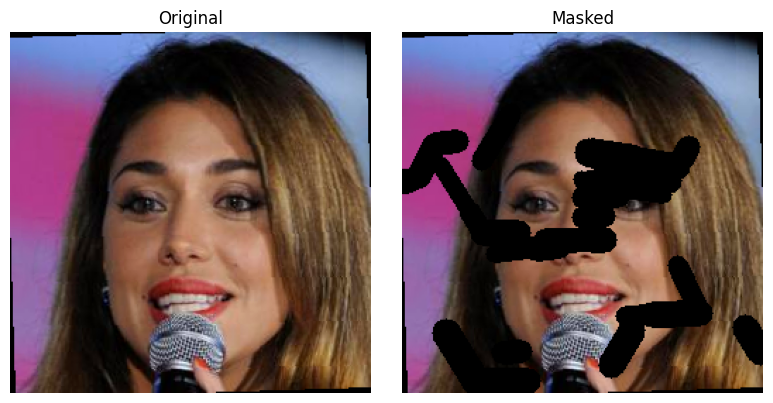

In [12]:
opt = SimpleNamespace(
    img_file='celeba_hq_256',
    mask_type=[0, 1, 2, 4],
    isTrain=True,
    batchSize=4,
    no_shuffle=False,
    nThreads=0,
    loadSize=[256, 256],
    fineSize=[256, 256],
    resize_or_crop='resize_and_crop',
    no_augment=False,
    no_flip=False,
    no_rotation=False,
)

train_loader = make_dataloader(opt)
batch = next(iter(train_loader))

img = batch['img']
mask = batch['mask']
img_path = batch['img_path']

print('train_loader ready')
print('img shape:', tuple(img.shape), 'dtype:', img.dtype, 'min/max:', float(img.min()), float(img.max()))
print('mask shape:', tuple(mask.shape), 'dtype:', mask.dtype, 'min/max:', float(mask.min()), float(mask.max()))
print('sample path:', img_path[0])

sample_img = img[0].detach().cpu()
sample_mask = mask[0].detach().cpu()
if sample_mask.dim() == 3:
    sample_mask_2d = sample_mask[0]
else:
    sample_mask_2d = sample_mask

masked_img = sample_img * sample_mask_2d.unsqueeze(0)

orig_np = sample_img.permute(1, 2, 0).clamp(0, 1)
masked_np = masked_img.permute(1, 2, 0).clamp(0, 1)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(orig_np)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(masked_np)
plt.title('Masked')
plt.axis('off')

plt.tight_layout()
plt.show()


In [13]:
opt = SimpleNamespace(
    img_file='celeba_hq_256',
    mask_type=[0, 1, 2, 4],
    isTrain=True,
    batchSize=4,
    no_shuffle=False,
    nThreads=0,
    loadSize=[256, 256],
    fineSize=[256, 256],
    resize_or_crop='resize_and_crop',
    no_augment=False,
    no_flip=False,
    no_rotation=False,
)

full_loader = make_dataloader(opt)
dataset = full_loader.dataset
total_samples = 6000
train_samples = 5000
val_samples = 1000

subset_idx = torch.randperm(len(dataset))[:total_samples].tolist()
train_idx = subset_idx[:train_samples]
val_idx = subset_idx[train_samples:train_samples + val_samples]

# Keep train and validation disjoint while reusing the same sampled subset.
train_subset = Subset(dataset, train_idx)
val_subset = Subset(dataset, val_idx)

loader_kwargs = dict(
    batch_size=opt.batchSize,
    num_workers=int(opt.nThreads),
    pin_memory=torch.cuda.is_available(),
)
if int(opt.nThreads) > 0:
    loader_kwargs['persistent_workers'] = True
    loader_kwargs['prefetch_factor'] = 2

train_loader = DataLoader(train_subset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_subset, shuffle=False, **loader_kwargs)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
G = Generator(use_input_noise=True)
D = Discriminator(in_channels=3, use_spectral_norm=True)

# Resume training from the latest checkpoint if it exists.
history = train_model(
    G, D, train_loader,
    epochs=40,
    lr=1e-4,
    device=device,
    use_perceptual_style=True,
    ckpt_path='checkpoints/spaformer_latest.pt',
    load_ckpt=True,
    save_ckpt=True,
    save_every=5,
)
history[-1]

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 226MB/s] 


Epoch 1/40:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1 | D: 0.6690 | G: 1.3126 | L1: 0.1133, G_per: 1.6250, G_style: 0.0039


Epoch 2/40:   0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch 39/40:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 39 | D: 0.6700 | G: 0.5765 | L1: 0.0492, G_per: 1.1184, G_style: 0.0014


Epoch 40/40:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 40 | D: 0.6692 | G: 0.5852 | L1: 0.0504, G_per: 1.1427, G_style: 0.0014
Saved checkpoint: checkpoints/spaformer_latest.pt


{'loss_d': 0.6691581866741181,
 'loss_g': 0.5851938263773918,
 'loss_g_adv': 0.7351082209348678,
 'loss_g_l1': 0.05040670902282,
 'loss_g_per': 1.1426849786043167,
 'loss_g_sty': 0.0013880311765242367}

## Evaluation

### Qualitative Evaluation
Reloads the latest generator checkpoint before visual inspection.
- Runs inference on one batch and shows masked input, raw output, completed image, and ground truth.


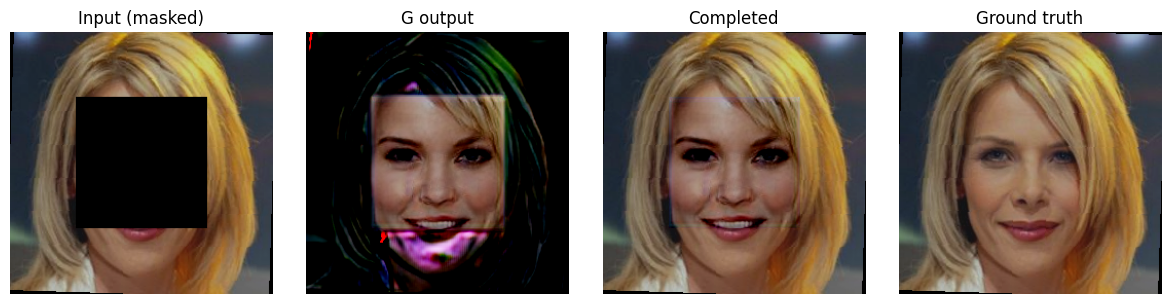

In [29]:
# Reload the latest generator checkpoint before qualitative evaluation.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
ckpt = torch.load('checkpoints/spaformer_latest.pt', map_location=device, weights_only=False)
G = Generator(use_input_noise=True)
# Rebuild G, restore weights, and run inference on one training batch for visualization.
G.load_state_dict(ckpt['G'])
G.to(device)
G.eval()

batch = next(iter(train_loader))
img_truth = batch['img'].to(device)
mask = batch['mask'].to(device)

img_m = img_truth * mask

with torch.no_grad():
    pred = G(img_m, mask)
    completed = composite_with_known_regions(pred, img_m, mask, known_is_one=True)

x_in = img_m[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
x_out = pred[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
x_comp = completed[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
x_gt = img_truth[0].detach().cpu().permute(1, 2, 0).clamp(0, 1)

plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1); plt.imshow(x_in);   plt.title("Input (masked)"); plt.axis("off")
plt.subplot(1, 4, 2); plt.imshow(x_out);  plt.title("G output");        plt.axis("off")
plt.subplot(1, 4, 3); plt.imshow(x_comp); plt.title("Completed");       plt.axis("off")
plt.subplot(1, 4, 4); plt.imshow(x_gt);   plt.title("Ground truth");    plt.axis("off")
plt.tight_layout()
plt.show()  


### Validation Metrics
Evaluates the latest checkpoint on the held-out validation split.
- Computes PSNR/SSIM after compositing predictions with known regions.
- Computes FID from InceptionV3 features on the same validation split.


In [ ]:
# Reload the latest checkpoint and report PSNR/SSIM/FID on the held-out validation split.
def validate_model(G, val_loader, device='cuda', ckpt_path='checkpoints/spaformer_latest.pt', inception_model=None):
    """
    Evaluates PSNR, SSIM, and FID on the held-out validation loader.
    """
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    G.load_state_dict(ckpt['G'])
    G.to(device)
    G.eval()

    # Accumulate image-quality metrics over the fixed validation split.
    total_psnr = 0.0
    total_ssim = 0.0
    count = 0
    real_batches = []
    fake_batches = []

    print(f"Starting validation on {len(val_loader.dataset)} samples...")
    
    with torch.no_grad():
        for batch in val_loader:
            img_truth, mask = unpack_batch(batch, device)
            img_m = img_truth * mask
            
            pred_fake = G(img_m, mask)
            img_fake = composite_with_known_regions(pred_fake, img_m, mask, known_is_one=True)
            
            img_fake_norm = (img_fake + 1.0) / 2.0
            img_truth_norm = (img_truth + 1.0) / 2.0
            
            batch_psnr = psnr(img_fake_norm, img_truth_norm)
            batch_ssim = ssim(img_fake_norm, img_truth_norm)
            
            total_psnr += batch_psnr.item()
            total_ssim += batch_ssim.item()
            count += 1
            real_batches.append(img_truth_norm.cpu())
            fake_batches.append(img_fake_norm.cpu())

    avg_psnr = total_psnr / count
    avg_ssim = total_ssim / count
    real_images = torch.cat(real_batches, dim=0)
    fake_images = torch.cat(fake_batches, dim=0)
    fid_score = fid_from_images(real_images, fake_images, model=inception_model, device=device)
    
    print("-" * 30)
    print(f"Validation Results:")
    print(f"Average PSNR: {avg_psnr:.4f} dB")
    print(f"Average SSIM: {avg_ssim:.4f}")
    print(f"FID: {fid_score:.4f}")
    print("-" * 30)
    
    return avg_psnr, avg_ssim, fid_score


### Final Evaluation
Loads the metric helpers from `evaluation.py` and evaluates the latest checkpoint end-to-end.

In [ ]:
# Load metric helpers from the external evaluation script without modifying it.
import importlib.util

eval_candidates = [
    Path('evaluation.py'),
    Path('new/Spa-Former/evaluation.py'),
]
eval_path = next((p for p in eval_candidates if p.exists()), None)
if eval_path is None:
    raise FileNotFoundError('Could not find evaluation.py from the notebook runtime.')

spec = importlib.util.spec_from_file_location('spaformer_eval', eval_path)
evaluation_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(evaluation_module)
psnr = evaluation_module.psnr
ssim = evaluation_module.ssim
fid_from_images = evaluation_module.fid_from_images
load_inception_model = evaluation_module.load_inception_model

# Rebuild the generator from the latest checkpoint, then report PSNR/SSIM/FID on val_loader.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
G_final = Generator(use_input_noise=True)
inception_model = load_inception_model(device=device)
final_psnr, final_ssim, final_fid = validate_model(
    G_final,
    val_loader,
    device=device,
    ckpt_path='checkpoints/spaformer_latest.pt',
    inception_model=inception_model,
)

print({'final_psnr': final_psnr, 'final_ssim': final_ssim, 'final_fid': final_fid})


Starting validation on 1000 samples...
------------------------------
Validation Results:
Average PSNR: 26.3649 dB
Average SSIM: 0.8658
FID: 25.0701
------------------------------
{'final_psnr': 26.364874225616454, 'final_ssim': 0.8658005893230438, 'final_fid': 25.070140912309856}


### Loss Curves
Plots the tracked training losses from `history`.
- Uses the per-epoch values returned by `train_model`.
- Makes it easier to inspect generator, discriminator, and reconstruction trends.


Successfully loaded history for 35 epochs from checkpoint.


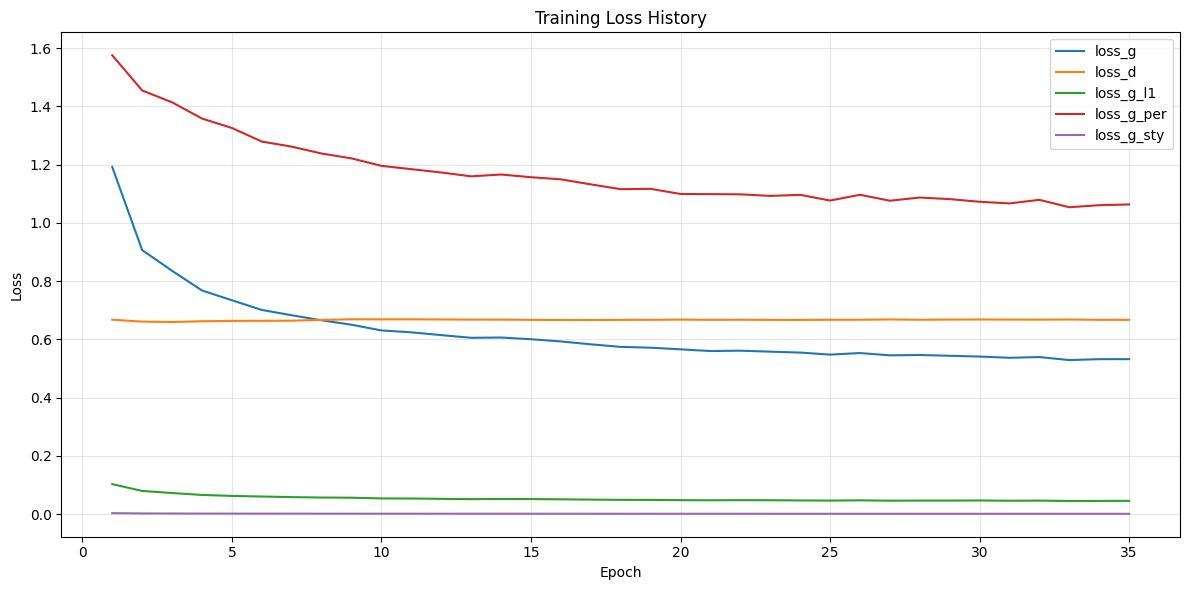

In [32]:
# 1. Load the checkpoint and extract history
ckpt_path = 'checkpoints/spaformer_latest.pt'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

try:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    history = ckpt.get('history', [])
    print(f"Successfully loaded history for {len(history)} epochs from checkpoint.")
except FileNotFoundError:
    print(f"Checkpoint not found at {ckpt_path}")
    history = []

# 2. Plot the loss curve if history exists
if not history:
    print("No history available to plot.")
else:
    epochs = range(1, len(history) + 1)
    
    loss_keys = ['loss_g', 'loss_d', 'loss_g_l1', 'loss_g_per', 'loss_g_sty'] 
    
    available_keys = [key for key in loss_keys if key in history[0]]
    
    if not available_keys:
        raise ValueError('No recognized loss keys were found in history.')
    
    plt.figure(figsize=(12, 6))
    for key in available_keys:
        values = [epoch_log[key] for epoch_log in history]
        plt.plot(epochs, values, label=key)
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss History')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()